In [558]:
import numpy as np
import scipy
import scipy.integrate
import matplotlib.pyplot as plt
import pyreadr
import pandas as pd
import sympy as sp

#import M2 data
M2 = pyreadr.read_r('/Users/anjalishah/Desktop/Senior_Thesis/full_2018_data_M2_Bering_combined_data.RDS')
M2 = M2[None]

M2=M2.set_index(M2.index.astype(int))
M2

,time_ak,full_O2,full_saturation_O2,full_chla,full_temperature,full_salinity,full_doy,approxPAR,time_gmt,air_tempC,...,cb_mean_tempC_int,t,kz,N,h,do2_dz_at_MLD_smoothed_boosted,doy.y,fmlb_term_mumol_per_kg_per_second,h_smooth_meters,iz
0,2018-05-01 23:00:00,338.542823,93.850346,1.140632,3.707315,32.059670,121.0,NaN,2018-05-02 00:00:00,3.8,...,3.8,NaN,NaN,NaN,NaN,NaN,121,2.510000e-05,16.040017,600.0
1,2018-05-02 00:00:00,340.833953,94.420655,0.528858,3.685249,32.038726,121.0,1035.6077,2018-05-02 01:00:00,4.1,...,3.8,NaN,NaN,NaN,NaN,NaN,121,2.090000e-05,17.333108,600.0
2,2018-05-02 01:00:00,342.079872,94.662048,0.760485,3.644305,32.025575,121.0,1238.0130,2018-05-02 02:00:00,4.1,...,3.8,NaN,NaN,NaN,NaN,NaN,121,1.760000e-05,18.565663,600.0
3,2018-05-02 02:00:00,343.325790,94.903442,0.992112,3.603360,32.012424,121.0,1047.3983,2018-05-02 03:00:00,4.0,...,3.8,NaN,NaN,NaN,NaN,NaN,121,1.490000e-05,19.746918,600.0
4,2018-05-02 03:00:00,344.064635,94.893928,0.956638,3.517202,31.993301,121.0,646.5179,2018-05-02 04:00:00,3.6,...,3.8,NaN,NaN,NaN,NaN,NaN,121,1.270000e-05,20.883307,600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3665,2018-10-01 16:00:00,283.044887,89.094355,3.606080,10.227915,31.844964,274.0,0.0000,2018-10-01 17:00:00,10.7,...,11.7,NaN,NaN,NaN,NaN,NaN,274,1.670000e-07,37.171765,600.0
3666,2018-10-01 17:00:00,283.266056,89.170021,3.766137,10.231230,31.844287,274.0,3.9302,2018-10-01 18:00:00,10.8,...,11.7,NaN,NaN,NaN,NaN,NaN,274,2.550000e-07,37.128667,600.0
3667,2018-10-01 18:00:00,283.487226,89.245686,3.926194,10.234544,31.843611,274.0,82.5342,2018-10-01 19:00:00,10.6,...,11.7,NaN,NaN,NaN,NaN,NaN,274,3.510000e-07,37.084248,600.0
3668,2018-10-01 19:00:00,283.693629,89.316676,3.999519,10.237335,31.844625,274.0,237.7771,2018-10-01 20:00:00,10.6,...,11.7,NaN,NaN,NaN,NaN,NaN,274,4.530000e-07,37.038501,600.0


Text(0, 0.5, 'Temp °C')

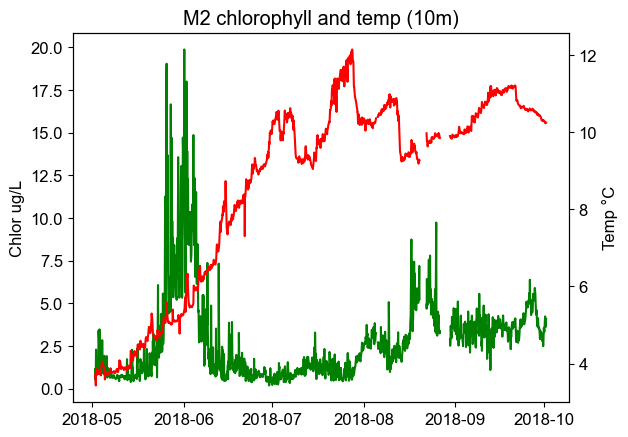

In [559]:
fig, ax1 = plt.subplots()
ax1.plot(M2['time_ak'], M2['full_chla'], color='green')
ax2 = ax1.twinx()
ax2.plot(M2['time_ak'], M2['full_temperature'], color='red')
plt.title('M2 chlorophyll and temp (10m)')
plt.xlabel('Time')
ax1.set_ylabel('Chlor ug/L')
ax2.set_ylabel('Temp °C')

In [560]:
M2[M2['time_ak'].astype(str).str.contains('2018-08')]

,time_ak,full_O2,full_saturation_O2,full_chla,full_temperature,full_salinity,full_doy,approxPAR,time_gmt,air_tempC,...,cb_mean_tempC_int,t,kz,N,h,do2_dz_at_MLD_smoothed_boosted,doy.y,fmlb_term_mumol_per_kg_per_second,h_smooth_meters,iz
2185,2018-08-01 00:00:00,296.447790,94.382488,2.493489,10.341725,31.834732,212.0,220.0912,2018-08-01 01:00:00,9.9,...,10.3,NaN,0.000021,0.044792,NaN,2.858738,212,-4.300000e-07,20.837833,600.0
2186,2018-08-01 01:00:00,296.453825,94.395873,2.499340,10.347110,31.835417,212.0,218.1261,2018-08-01 02:00:00,9.9,...,10.3,NaN,0.000021,0.044792,NaN,2.858738,212,-5.450000e-07,20.875008,600.0
2187,2018-08-01 02:00:00,296.459859,94.409258,2.505190,10.352495,31.836101,212.0,206.3355,2018-08-01 03:00:00,9.9,...,10.3,NaN,0.000021,0.044792,NaN,2.858738,212,-6.470000e-07,20.914647,600.0
2188,2018-08-01 03:00:00,296.305805,94.219686,2.580404,10.288456,31.819284,212.0,273.1489,2018-08-01 04:00:00,10.0,...,10.3,NaN,0.000021,0.044792,NaN,2.858738,212,-7.270000e-07,20.955896,600.0
2189,2018-08-01 04:00:00,296.151751,94.030114,2.655618,10.224416,31.802466,212.0,153.2778,2018-08-01 05:00:00,9.9,...,10.3,NaN,0.000021,0.044792,NaN,2.858738,212,-7.800000e-07,20.997939,600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2924,2018-08-31 19:00:00,295.009986,92.556742,3.505512,9.869315,31.851545,243.0,45.1973,2018-08-31 20:00:00,9.6,...,11.3,NaN,0.000018,0.043068,NaN,5.200728,243,-1.430000e-06,31.084660,600.0
2925,2018-08-31 20:00:00,295.275590,92.634196,3.357900,9.864328,31.858682,243.0,186.6845,2018-08-31 21:00:00,9.6,...,11.3,NaN,0.000018,0.043068,NaN,5.200728,243,-1.750000e-06,31.158259,600.0
2926,2018-08-31 21:00:00,295.931292,92.836849,3.536700,9.862705,31.859117,243.0,202.4053,2018-08-31 22:00:00,9.5,...,11.3,NaN,0.000018,0.043068,NaN,5.200728,243,-2.050000e-06,31.249883,600.0
2927,2018-08-31 22:00:00,296.586994,93.039502,3.715501,9.861082,31.859553,243.0,267.2536,2018-08-31 23:00:00,9.5,...,11.3,NaN,0.000018,0.043068,NaN,5.200728,243,-2.310000e-06,31.358995,600.0


/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_52649/2387293336.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I=(pd.DataFrame((M2['approxPAR'].fillna(method='bfill')))) #define irradiance function as PAR data from M2, convert to Ein m^2 s^2
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_52649/2387293336.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  T=pd.DataFrame(M2['full_temperature'].fillna(method='bfill')) #define temp function as temp data from M2


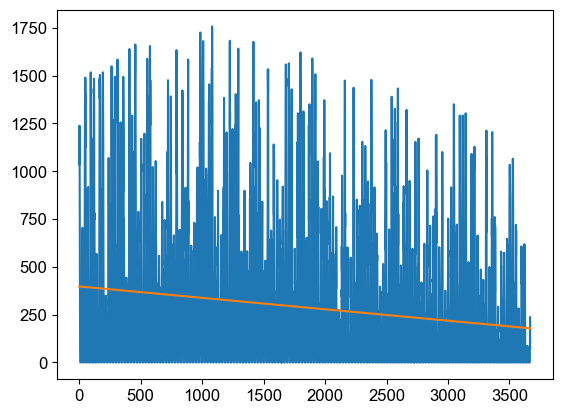

In [672]:
#import, smooth, interpolate: Irradiance, Temperature
time = [0, M2.index[3669]]
time_eval = np.linspace(M2.index[0], M2.index[3669], 3670)

I=(pd.DataFrame((M2['approxPAR'].fillna(method='bfill')))) #define irradiance function as PAR data from M2, convert to Ein m^2 s^2
I_smoothed= I #.rolling(24, min_periods=1).mean()
I_interp = scipy.interpolate.interp1d(time_eval, I_smoothed['approxPAR'], kind='linear', fill_value = 'extrapolate')

T=pd.DataFrame(M2['full_temperature'].fillna(method='bfill')) #define temp function as temp data from M2
T_smoothed= T #rolling(24, min_periods=1).mean()
T_interp = scipy.interpolate.interp1d(time_eval, T_smoothed['full_temperature'], kind='linear', fill_value = 'extrapolate')

plt.plot(I)

M2.index.values
best_fit = np.polyfit(M2.index.values, I_smoothed, deg=1)
best_fit

plt.plot(M2.index.values, best_fit[0]*M2.index.values + best_fit[1])

array([[-6.07809950e-04],
       [ 4.01915055e+00]])

In [673]:
mu = .06 #phyto max growth rate / hr-1 --> Jin et. al 
r = .0633 #temp coefficient deg-1 -->  Jin et. al 
r_g = .03 #temp coefficient deg-1 -->  Jin et. al 
R_g_0 = 9.23e-4 #max mortality rate at 0 degrees (h-1) -->  Jin et. al 
Vmax = 1e-5 #max nitrogen uptake rate (NO3 and NH4) -->  fNO3 in Jin et. al, defined as Vmax in Eslinger et. al ?? confused here... 
fNO3 = .01 #from Jin et. al, maybe this is wrong, unsure????
alpha = .05 # light --> photosynthesis conversion rate, mgC / [mg Chla h W m2] --> Eslinger et. al 
beta = 0 #photoinhibition coefficient mg C /(mg Chla h W m2) --> Eslinger et. al 
P_B_S = 3.25 #max photosynthesis rate, mcg C/(mgChlhr) --> Eslinger et. al 
k_s = 1.0 #MM half staturation constant, change to get small versus large cells!!!
#gamma_D = .006 #(h-1), averaged over: S, L, P (diff zooplankton types) -->  Jin et. al 
#gamma_F = .087 #(h-1), averaged over: S, L, P (diff zooplankton types) -->  Jin et. al 
#photo_slope = .055 #initial photosynthetic slope -->  Jin et. al 


In [674]:
#photosynthetic rate with irradiance -> create dimensionless value to compare with V_Frac

def P_B(I): 
    P_B = P_B_S*(1-(np.exp(-(alpha*I)/P_B_S)))*(np.exp((-beta*I)/P_B_S)) 
    P_frac = P_B/P_B_S
    return P_frac



In [707]:
def N_in(t):
    return 0.0208 # hr^-1 value from EPOC 2023 poster --> 

In [708]:
def V_frac(N): #create dimensionless nitrogen value to compare with V_frac
    V_N = Vmax * (N/(N+k_s))
    return V_N / Vmax 

In [709]:
#define rates function: here flagellate growth rates and diatom growth rates do not differ
def phyto_rates(T, N_frac, I_frac): 
    phyto_growth = mu * np.exp(r*T) * min(N_frac, I_frac) #growth, use minimum of dimensionless nitrogen and irradiance
    phyto_resp = .05 * mu * np.exp(r*T) #respiration
    phyto_mortality = R_g_0 * np.exp(r_g * T) #mortality
    return [phyto_growth, phyto_resp, phyto_mortality]



In [710]:
def gaussian(t, center, amp, width): 
    return amp * np.exp(-(t-center)**2 / (2*width**2))

In [757]:
#define growth rate function: relates phytoplankton growth rate to temperature 
#define npz system

def npz(t, X): #this model takes in temperature, nutrients (N), and irradiance (I)
    [N, P] = X
    Temp = T_interp(t)
    I_value = I_interp(t)
    PBI = P_B(I_value) #calculate dimensionaless irradiance
    V_frac_calc = V_frac(N)
    [phyto_growth, phyto_resp, phyto_mortality] = phyto_rates(Temp, V_frac_calc, PBI) #calculate phyto rates based on Temperature
    dN_dt = - (P*(phyto_growth-phyto_resp)) + N_in(t) #+ (gaussian(t, 2209, 0.3, 24))
    #dN_dt = N + #create new function here!
    dP_dt = P*(phyto_growth-phyto_resp-(6*phyto_mortality)) #scale by 0.001 to reduce over-grazing
    print(PBI)
    print(V_frac_calc)
    print(phyto_mortality)
    #rho_t[round(t)] = I_value
    return [dN_dt, dP_dt]


In [758]:
#initial condtions 
N0 = 0.5
P0 = 0.5

init = [N0, P0]

In [759]:
M2_model = scipy.integrate.solve_ivp(npz, y0 = init, t_span = time, t_eval=time_eval, method='Radau', dense_output=False)

0.999999879597574
0.3333333333333333
0.0010315818484924527
0.999999879597574
0.33582439565992717
0.0010311997148847343
0.999999879597574
0.3333333366447025
0.0010315818484924527
0.999999879597574
0.3333333333333333
0.0010315818484924527
0.999999879597574
0.3333333333333333
0.0010315655547180585
0.999999879597574
0.3333333333333333
0.0010315140747333522
0.999999879597574
0.3333333333333333
0.001031476766484148
0.999999879597574
0.33343987169037753
0.0010315655547180585
0.999999879597574
0.3337757360418208
0.0010315140747333522
0.999999879597574
0.3340184379037987
0.001031476766484148
0.999999879597574
0.3340184373674291
0.001031476766484148
0.999999879597574
0.3350713051163288
0.001031313856917343
0.9999999236746907
0.33832369356181685
0.0010307138420287856
0.9999999860759765
0.3406113478192664
0.0010300223251139633
0.999999879597574
0.3350713692600871
0.001031313856917343
0.9999999236746907
0.33832381159959285
0.0010307138420287856
0.9999999860759765
0.3406126929224537
0.00103002232511

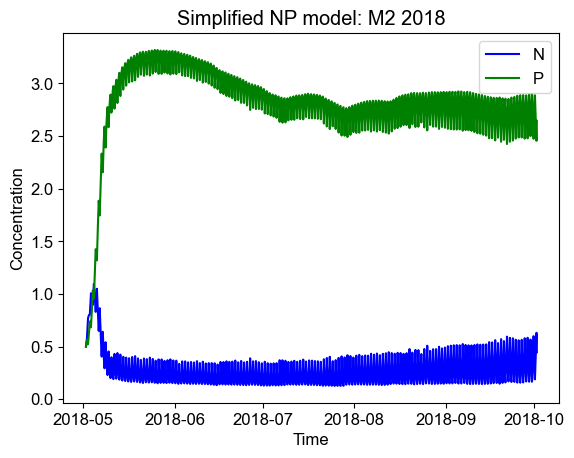

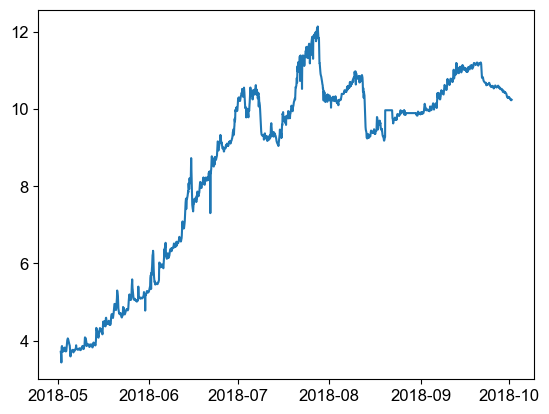

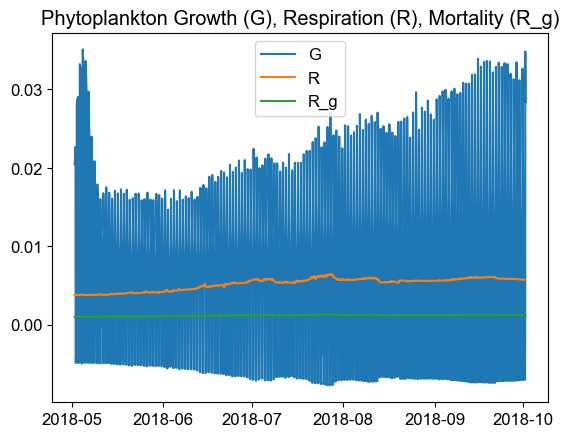

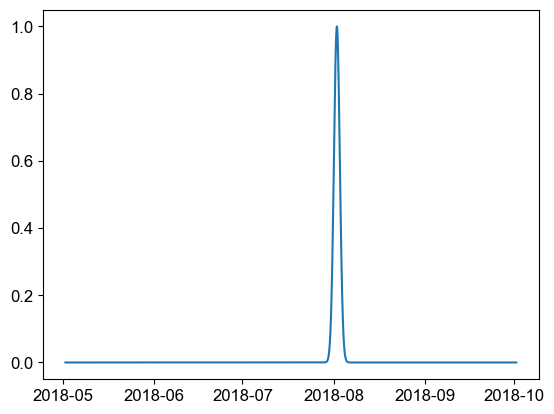

In [762]:
timestamp = M2['time_ak']
plt.figure()

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12 
plt.plot(timestamp, M2_model.y[0], color='blue') #N
plt.plot(timestamp, M2_model.y[1], color='green') #P
plt.title('Simplified NP model: M2 2018')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend(['N', 'P'])

plt.figure()
#plt.plot(timestamp, I_smoothed)
plt.plot(timestamp, T_smoothed)

N = M2_model.y[0]
G = np.zeros(len(time_eval))
R=np.zeros(len(time_eval))
R_g=np.zeros(len(time_eval))

N = M2_model.y[0]
P = M2_model.y[1]

for i,t in enumerate(time_eval): 
     G[i] = phyto_rates(T_interp(t), V_frac(N[t.astype(int)]), P_B(I_interp(t)))[0]
     R[i] = phyto_rates(T_interp(t), V_frac(N[t.astype(int)]), P_B(I_interp(t)))[1]
     R_g[i] = phyto_rates(T_interp(t), V_frac(N[t.astype(int)]), P_B(I_interp(t)))[2]

plt.figure()
plt.plot(timestamp, G-R-R_g)
plt.plot(timestamp, R)
plt.plot(timestamp, R_g)

plt.legend(['G', 'R', 'R_g'])
plt.title('Phytoplankton Growth (G), Respiration (R), Mortality (R_g)')

plt.figure()
plt.plot(timestamp, (gaussian(time_eval, 2209, 1, 24)))

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 3.667e+03, 3.668e+03,
       3.669e+03])

In [551]:
N = M2_model.y[0]
for i,t in enumerate(time_eval): 
    x = phyto_rates(T_interp(t), V_frac(N[t.astype(int)]), P_B(I_interp(t)))[0]

In [233]:
plt.plot(timestamp, phyto_rates)

0.9523809523809524

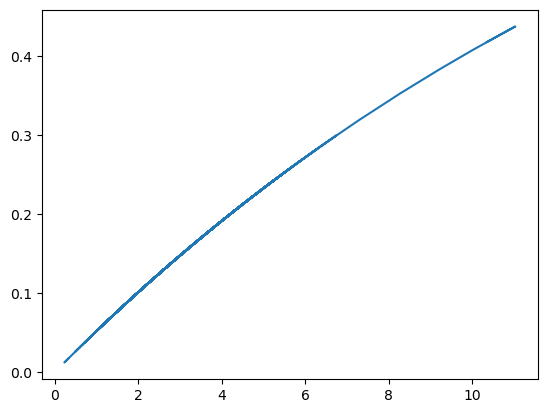

In [200]:
#determine alpha from the slope of this line!!! 
plt.plot(I_smoothed, P_B(I_smoothed))

